In [3]:
!pip install pandas

In [4]:
# import libraries
import pandas as pd
import io

# mount google drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Sounding_Spirit/dimension_data_seperate.csv')
df.head()

,FILENAME ID,HEIGHT,WIDTH
0,xxxx-Worldf-MTS,27.5,20.0
1,1925-Comple-MTS,20.0,13.5
2,1923-NewHar-MTS,17.5,24.0
3,1923-Eightn-MTS,30.5,24.0
4,1923-Christ-MTS,26.5,18.0


In [6]:
# generate ratio and date information
df["ratio"] = df["HEIGHT"]/df["WIDTH"]
df["date"] = df["FILENAME ID"]
for x in df.index:
  df.loc[x,"date"] = df.loc[x,"date"][:4]
  if not df.loc[x,"date"].isnumeric():
    df=df.drop(index=x)
    x=x-1
df["date"]=df["date"].astype(float)
df

,FILENAME ID,HEIGHT,WIDTH,ratio,date
1,1925-Comple-MTS,20.0,13.5,1.481481,1925.0
2,1923-NewHar-MTS,17.5,24.0,0.729167,1923.0
3,1923-Eightn-MTS,30.5,24.0,1.270833,1923.0
4,1923-Christ-MTS,26.5,18.0,1.472222,1923.0
5,1923-Cheerf-MTS,19.5,13.5,1.444444,1923.0
...,...,...,...,...,...
930,1914-Newgos-EMU,19.5,13.5,1.444444,1914.0
931,1916-Worshi-EMU,20.0,14.0,1.428571,1916.0
933,1922-Victo1-EMU,21.5,13.5,1.592593,1922.0
934,1925-Excell-EMU,21.5,15.0,1.433333,1925.0


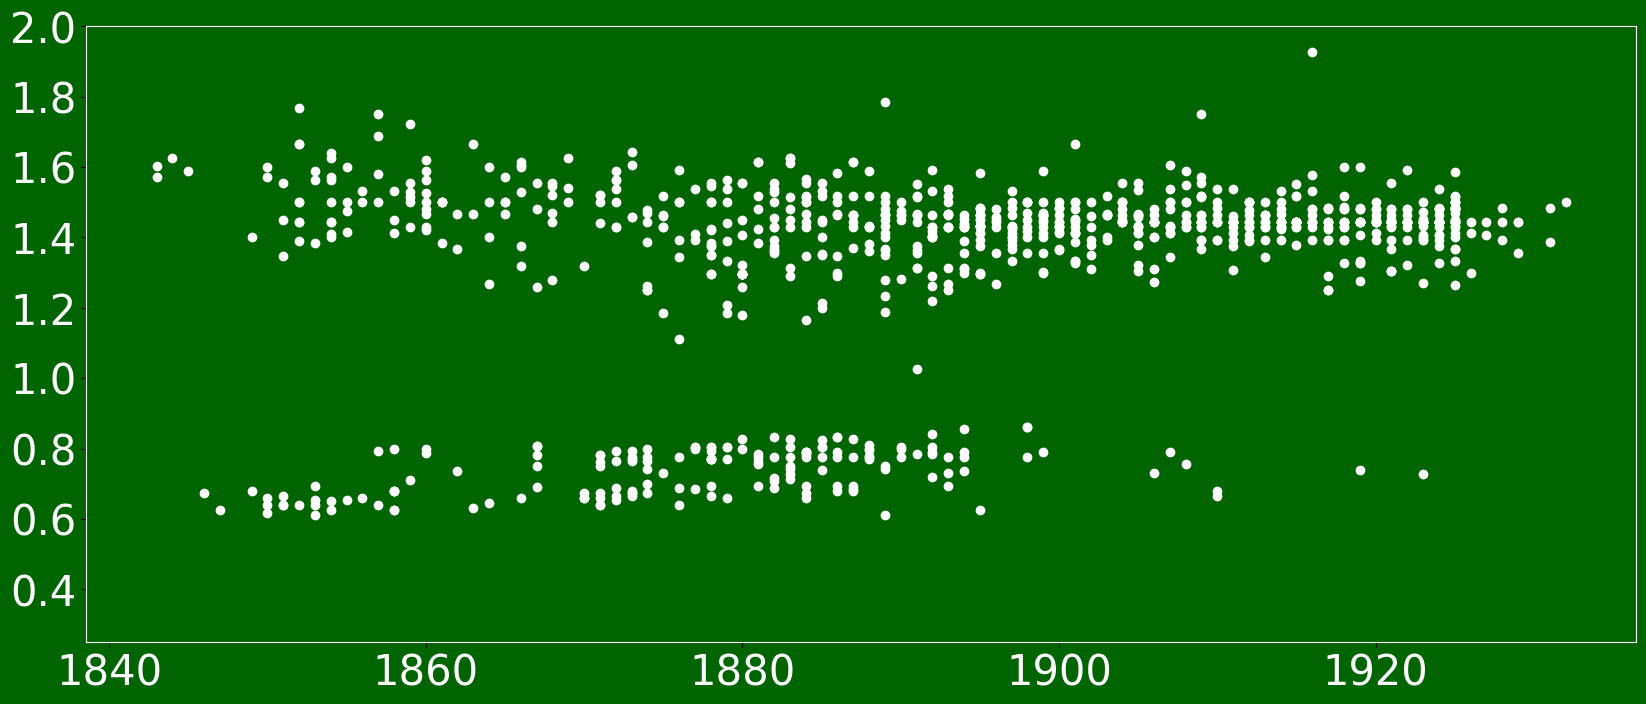

In [30]:
# plot date vs ratio
df = df[df['date'] >= 1840]
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 8), facecolor='darkgreen')  # Set figure size
plt.scatter(df['date'], df['ratio'], color='white')  # Scatter plot with red color
plt.ylim(0.25, 2)  # Set y-axis limits
ax = plt.gca()
ax.set_facecolor('darkgreen')  # Set axis background color
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['right'].set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
plt.xticks(color='white', fontsize=30)
plt.yticks(color='white', fontsize=30)
# plt.gca().set_facecolor('none')  # Make background transparent
plt.savefig('demo.png',transparent=True)